# Notebook 04 — Healthy Mouse ECG Template and Distance-to-Healthy Scoring

**Project:** Reproducible Signal Processing and Multivariate Analysis of Preclinical Mouse ECG Data  
**Author:** Vishvasundar (MSc, University College Cork)  
**MSc thesis project**

## Purpose (one-class / novelty detection framing)

Define what a **healthy heartbeat** looks like and produce a **distance-to-healthy** score
for every animal in the dataset.

1. **Healthy reference.** Control animals match the template with only minor variability
   (three legitimate sources: the heartbeat itself, electrode placement / amplitude
   gain, and breathing / slow baseline drift).
2. **Novelty score seed.** Per-animal RMSE and correlation distance feed Phase 4.
   Animals with no clean averaged beat get NULL distances — the null is *informative*,
   not a failure.

## Three-step pipeline
- **Step 1** — Select the clean animals (seed + reproducible widening criterion).
- **Step 2** — Build raw-mV and normalised templates; compute variability band.
- **Step 3** — Score every animal; produce ranked distance table.

## RR-fraction warping (primary metric)
Beats are compared in **fraction-of-RR time**, not absolute ms. T-waves from animals at
different heart rates are shifted to different absolute positions in a fixed-ms window —
a pure heart-rate confound. Expressing time as a fraction of the median RR interval
("each heartbeat lasts 1 unit of time") removes this confound and makes the
metric sensitive to repolarisation shape, where doxorubicin toxicity shows.
Fixed-ms scores are retained alongside for the audit.

> NB02 is **not modified**. Signal-processing helpers are adapted from NB02
> (logic unchanged, reformatted); shared-module refactor is a future cleanup item.

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, find_peaks, iirnotch
from scipy.stats import pearsonr

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR    = PROJECT_ROOT / 'data'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# -- NB02 signal-processing constants (unchanged) ----------------------------
FS                = 1000
BANDPASS_LOW_HZ   = 0.5
BANDPASS_HIGH_HZ  = 150.0
BANDPASS_ORDER    = 2
REFRACTORY_MS     = 55
MIN_RR_MS         = 75
PRE_R_MS          = 100
POST_R_MS         = 150
BEATS_TO_AVERAGE  = 4
HR_ACCEPT_LOW     = 300
HR_ACCEPT_HIGH    = 700
GAP_MIN_S         = 10
GAP_MAX_S         = 120
GAP_MAX_LONG_S    = 900
LONG_USE_S        = 60
SINGLE_FALLBACK_S = 30
EXCLUDE_KEYWORDS  = ('oc 1', 'oc 2', 'oc1', 'oc2', 'jugular', 'jugcan', 'injection', 'inject')
END_KEYWORDS      = ('end', 'done', 'stop')
START_HINTS       = ('baseline', 'ecg', 'start')

# -- Meeting reference line (NOT a decision boundary) -----------------------
CORR_ADMIT_MIN = 0.95
# The 0.95 value from the meeting is kept as a reference marker on plots.
# It is NOT applied as a binary gate: the score distribution is unimodal
# with no natural gap at this value (gap = 0.003 between highest below and
# lowest above). See histogram cell for visual confirmation.
#
# Seed validation (warped template vs individual seeds):
#   Seed 201 (499 bpm): corr = 0.9847
#   Seed 146 (406 bpm): corr = 0.9803
# Inter-seed cross-corr: 0.6068 (fixed-ms) -> 0.9310 (warped). See cell-normalise.

RMSE_ADMIT_TOL      = 0.15   # kept for audit table display; not a gate
CORR_ADMIT_MIN_FIXEDMS = 0.90  # pre-warping legacy reference

# -- RR-fraction warping parameters ------------------------------------------
WARP_PRE_FRAC  = 0.15
WARP_POST_FRAC = 0.60
WARP_GRID_N    = 200

# -- Rhythm variability flag --------------------------------------------------
RR_CV_FLAG_THRESHOLD = 0.15
# rr_cv above this marks morphology-clean + rhythm-irregular animals.
# Seed range: rr_cv = 0.0705 (201) to 0.1038 (146).
# 0.15 is ~50% above the higher seed; these animals are NOT classified 'healthy'.
# They form a distinct informative category (rhythm effect without morphology change).

# -- Seeds: the ONLY hardcoded animal IDs ------------------------------------
SEED_ANIMAL_IDS = [201, 146]

# -- Hard excludes -----------------------------------------------------------
HARD_EXCLUDE_IDS = frozenset({
    106,   # clean mean beat but elevated RR CV from edge-window outliers
    109,   # NEEDS_REVIEW: HR 171 bpm
    111,   # NEEDS_REVIEW: HR 284 bpm -- pathological morphology suspected
    113,   # NEEDS_REVIEW: HR 213 bpm -- signal quality inadequate
    115,   # OK-HR but rr_std=717 ms -- rhythm too variable for template
    117,   # OK-HR but qrs_std=43 ms -- morphology outlier
    120,   # NEEDS_REVIEW: HR 93 bpm -- bradycardic
})

print(f'Project root       : {PROJECT_ROOT}')
print(f'Data folder        : {DATA_DIR}')
print(f'Corr ref (meeting) : {CORR_ADMIT_MIN} (reference marker only, not a gate)')
print(f'rr_cv flag         : > {RR_CV_FLAG_THRESHOLD}')
print(f'Seeds              : {SEED_ANIMAL_IDS}')
print(f'Hard excludes      : {sorted(HARD_EXCLUDE_IDS)}')
print(f'Warp grid          : -{WARP_PRE_FRAC}*RR to +{WARP_POST_FRAC}*RR  ({WARP_GRID_N} pts)')

Project root       : E:\data_vishva
Data folder        : E:\data_vishva\data
Corr ref (meeting) : 0.95 (reference marker only, not a gate)
rr_cv flag         : > 0.15
Seeds              : [201, 146]
Hard excludes      : [106, 109, 111, 113, 115, 117, 120]
Warp grid          : -0.15*RR to +0.6*RR  (200 pts)


In [2]:
# -- File parsing helpers (adapted from NB02, logic unchanged) ----------------

def parse_filename(path):
    nums = re.findall(r'\d+', path.stem)
    try:
        if len(nums) >= 4:
            y_str, m, d, a = nums[0], int(nums[1]), int(nums[2]), int(nums[3])
            y = int(y_str[-4:]) if len(y_str) > 4 else int(y_str)
            return a, pd.Timestamp(year=y, month=m, day=d)
        if len(nums) == 3:
            y_str, m, a = nums[0], int(nums[1]), int(nums[2])
            y = int(y_str[-4:]) if len(y_str) > 4 else int(y_str)
            return a, pd.Timestamp(year=y, month=m, day=1)
    except (ValueError, TypeError) as exc:
        print(f'  WARNING parse_filename: cannot parse {path.name!r} -- {exc}')
    return None, None


def parse_header_and_layout(path):
    info = {}; n_header = 0; first_data_row = None
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            s = line.lstrip()
            if not s or s[0].isdigit() or s[0] in '+-.':
                first_data_row = line.rstrip('\n'); break
            n_header += 1
            if '=' in line:
                key, _, rest = line.partition('=')
                info[key.strip()] = rest.strip('\n').strip('\t').split('\t')
    titles = [t.strip() for t in info.get('ChannelTitle', []) if t.strip()]
    n_channels = max(len(titles), 1)
    n_cols_first_row = len(first_data_row.split('\t')) if first_data_row else (n_channels + 1)
    lead_cols = max(1, n_cols_first_row - n_channels)
    ch3_idx = None
    for i, t in enumerate(titles):
        if t.lower() == 'channel 3':
            ch3_idx = i; break
    if ch3_idx is None:
        ch3_idx = 0
    ecg_col = lead_cols + ch3_idx
    return n_header, lead_cols, ecg_col, titles


_MARKER_RE = re.compile(r'#([*1-3])')

def _looks_like_end(text):      return any(k in text.lower() for k in END_KEYWORDS)
def _looks_like_excluded(text): return any(k in text.lower() for k in EXCLUDE_KEYWORDS)
def _looks_like_baseline(text): return 'baseline' in text.lower().replace('basline', 'baseline')


def load_ecg_file(path, n_header, ecg_col):
    voltages = []; markers = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for _ in range(n_header): f.readline()
        for line in f:
            stripped = line.rstrip('\n')
            parts = stripped.split('\t')
            if len(parts) <= ecg_col: continue
            try: v = float(parts[ecg_col])
            except ValueError: v = np.nan
            voltages.append(v)
            m = _MARKER_RE.search(stripped)
            if m:
                prefix = m.group(1)
                ann_text = stripped[m.start():].strip()
                markers.append((len(voltages) - 1, ann_text, prefix))
    voltage = np.asarray(voltages, dtype=float)
    if np.isnan(voltage).any():
        idx = np.arange(len(voltage)); good = ~np.isnan(voltage)
        if good.any(): voltage = np.interp(idx, idx[good], voltage[good])
    return voltage, markers


def find_baseline_window(markers, n_samples, fs=FS):
    MIN_GAP  = GAP_MIN_S      * fs
    MAX_GAP  = GAP_MAX_S      * fs
    LONG_GAP = GAP_MAX_LONG_S * fs
    LONG_USE = LONG_USE_S     * fs
    FALLBACK = SINGLE_FALLBACK_S * fs
    tagged = []
    for idx, text, prefix in markers:
        if _looks_like_excluded(text): continue
        end_like = _looks_like_end(text)
        tagged.append({'idx': idx, 'text': text, 'prefix': prefix, 'end': end_like})
    starts = [m for m in tagged if not m['end']]
    ends   = [m for m in tagged if m['end']]
    def _try(_starts, _ends, lo, hi, label):
        for s in _starts:
            for e in _ends:
                if e['idx'] <= s['idx']: continue
                gap = e['idx'] - s['idx']
                if lo <= gap <= hi: return s, e, label
        return None
    for pre in ('*', '1', '2', '3'):
        result = _try([m for m in starts if m['prefix'] == pre],
                      [m for m in ends   if m['prefix'] == pre],
                      MIN_GAP, MAX_GAP, f'A_same_{pre}')
        if result:
            s, e, label = result
            return s['idx'], min(e['idx'], n_samples), label, s['text'], e['text']
    result = _try(starts, ends, MIN_GAP, MAX_GAP, 'B_cross')
    if result:
        s, e, label = result
        return s['idx'], min(e['idx'], n_samples), label, s['text'], e['text']
    bl_starts = [m for m in starts if _looks_like_baseline(m['text'])]
    bl_ends   = [m for m in ends   if _looks_like_baseline(m['text'])]
    result = _try(bl_starts, bl_ends, MIN_GAP, LONG_GAP, 'C_long_baseline')
    if result:
        s, e, label = result
        end_idx = min(s['idx'] + LONG_USE, e['idx'], n_samples)
        return s['idx'], end_idx, label, s['text'], e['text']
    candidate = None
    for m in starts:
        if any(k in m['text'].lower() for k in START_HINTS):
            candidate = m; break
    if candidate is None and starts:  candidate = starts[0]
    if candidate is None and tagged:  candidate = tagged[0]
    if candidate is not None:
        end_idx = min(candidate['idx'] + FALLBACK, n_samples)
        return candidate['idx'], end_idx, 'D_single_30s', candidate['text'], None
    return None, None, 'no_markers', None, None


def bandpass_filter(x, fs=FS, low=BANDPASS_LOW_HZ, high=BANDPASS_HIGH_HZ, order=BANDPASS_ORDER):
    nyq = 0.5 * fs
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    y = filtfilt(b, a, x)
    for f0 in (50, 100, 150):
        bn, an = iirnotch(f0 / (fs / 2), Q=30)
        y = filtfilt(bn, an, y)
    return y


def _peaks_with_mad(sig, fs=FS, refractory_ms=REFRACTORY_MS):
    if sig.size == 0: return np.array([], dtype=int), np.nan, np.nan
    med = float(np.median(sig))
    mad = float(np.median(np.abs(sig - med)))
    if mad <= 0: return np.array([], dtype=int), med, mad
    height     = med + 4 * mad
    prominence = max(0.3 * mad, 0.005)
    distance   = int(refractory_ms * fs / 1000)
    peaks, _   = find_peaks(sig, height=height, distance=distance, prominence=prominence)
    return peaks, height, prominence


def detect_r_peaks(sig, fs=FS):
    def _hr(peaks):
        if len(peaks) < 2: return np.nan
        rr_ms = np.diff(peaks) * (1000.0 / fs)
        return 60000.0 / np.mean(rr_ms)
    pos_peaks, pos_h, _ = _peaks_with_mad(sig, fs)
    pos_hr = _hr(pos_peaks)
    pos_ok = HR_ACCEPT_LOW <= pos_hr <= HR_ACCEPT_HIGH if not np.isnan(pos_hr) else False
    if pos_ok: return pos_peaks, False, pos_hr, pos_h
    inv_peaks, inv_h, _ = _peaks_with_mad(-sig, fs)
    inv_hr = _hr(inv_peaks)
    inv_ok = HR_ACCEPT_LOW <= inv_hr <= HR_ACCEPT_HIGH if not np.isnan(inv_hr) else False
    if inv_ok: return inv_peaks, True, inv_hr, inv_h
    def _dist(hr):
        if np.isnan(hr): return np.inf
        if hr < HR_ACCEPT_LOW: return HR_ACCEPT_LOW - hr
        if hr > HR_ACCEPT_HIGH: return hr - HR_ACCEPT_HIGH
        return 0.0
    if _dist(inv_hr) < _dist(pos_hr): return inv_peaks, True, inv_hr, inv_h
    return pos_peaks, False, pos_hr, pos_h


def average_beats(sig, r_peaks, fs=FS, pre_ms=PRE_R_MS, post_ms=POST_R_MS,
                  group_size=BEATS_TO_AVERAGE):
    pre  = int(pre_ms  * fs / 1000)
    post = int(post_ms * fs / 1000)
    win_len = pre + post
    t_ms = (np.arange(win_len) - pre) * (1000.0 / fs)
    beats = [sig[r - pre: r + post] for r in r_peaks
             if r - pre >= 0 and r + post <= len(sig)]
    if not beats: return None, t_ms, None
    beats = np.vstack(beats)
    n_full_groups = len(beats) // group_size
    if n_full_groups == 0: return beats.mean(axis=0), t_ms, beats
    grouped = beats[:n_full_groups * group_size].reshape(n_full_groups, group_size, win_len)
    return grouped.mean(axis=1).mean(axis=0), t_ms, beats


print('NB02 helper functions loaded (adapted from NB02, logic unchanged).')

NB02 helper functions loaded (adapted from NB02, logic unchanged).


In [3]:
# Load every .txt file and build averaged beats.
# Mirrors the NB02 Part-1 loop but stores results in all_animal_beats
# (keyed by animal_id) for use across all three steps.

files = sorted(DATA_DIR.glob('*.txt'))
print(f'Found {len(files)} .txt files\n')

all_animal_beats = {}  # animal_id (int) -> record dict

for path in files:
    animal_id = None
    try:
        animal_id, _ = parse_filename(path)
        if animal_id is None:
            continue

        n_header, lead_cols, ecg_col, _ = parse_header_and_layout(path)
        voltage, markers = load_ecg_file(path, n_header, ecg_col)

        if voltage.size == 0:
            all_animal_beats[animal_id] = {'status': 'FAILED_FILE', 'n_beats': 0, 'mean_beat': None}
            continue
        if float(np.median(np.abs(voltage))) > 50:
            all_animal_beats[animal_id] = {'status': 'FAILED_COLUMN', 'n_beats': 0, 'mean_beat': None}
            continue

        start, end, _, _, _ = find_baseline_window(markers, len(voltage))
        if start is None:
            all_animal_beats[animal_id] = {'status': 'FAILED_ANNOTATION', 'n_beats': 0, 'mean_beat': None}
            continue

        segment = voltage[start:end]
        if segment.size < 2 * FS:
            all_animal_beats[animal_id] = {'status': 'FAILED_ANNOTATION', 'n_beats': 0, 'mean_beat': None}
            continue

        filtered = bandpass_filter(segment)
        peaks, inverted, hr, _ = detect_r_peaks(filtered)
        if inverted:
            filtered = -filtered

        rr_ms = np.diff(peaks) * (1000.0 / FS) if len(peaks) > 1 else np.array([])
        rr_cv        = (float(np.std(rr_ms, ddof=1) / np.mean(rr_ms))
                        if len(rr_ms) > 1 and np.mean(rr_ms) > 0 else np.nan)
        median_rr_ms = float(np.median(rr_ms)) if len(rr_ms) > 0 else np.nan

        if len(peaks) < 2:
            all_animal_beats[animal_id] = {
                'status': 'FAILED_PEAKS', 'n_beats': len(peaks),
                'hr': float(hr), 'rr_cv': np.nan, 'median_rr_ms': np.nan,
                'mean_beat': None,
            }
            continue

        mean_beat, t_ms, beats = average_beats(filtered, peaks)
        status = 'OK' if HR_ACCEPT_LOW <= hr <= HR_ACCEPT_HIGH else 'NEEDS_REVIEW'

        all_animal_beats[animal_id] = {
            'status':       status,
            'n_beats':      int(len(peaks)),
            'hr':           float(hr),
            'rr_cv':        rr_cv,
            'median_rr_ms': median_rr_ms,
            'mean_beat':    mean_beat,
            't_ms':         t_ms,
            'beats':        beats,
        }

    except Exception as exc:
        if animal_id is not None:
            all_animal_beats[animal_id] = {'status': 'FAILED_FILE', 'n_beats': 0, 'mean_beat': None}
        print(f'  ERROR {path.name}: {exc}')

ok_ids = sorted(a for a, v in all_animal_beats.items() if v['status'] == 'OK')
nr_ids = sorted(a for a, v in all_animal_beats.items() if v['status'] == 'NEEDS_REVIEW')
print(f'Loaded {len(all_animal_beats)} animals.')
print(f'  OK           : {len(ok_ids)}')
print(f'  NEEDS_REVIEW : {len(nr_ids)} -> {nr_ids}')
print(f'  Failed/other : {len(all_animal_beats) - len(ok_ids) - len(nr_ids)}')

Found 118 .txt files



Loaded 118 animals.
  OK           : 111
  NEEDS_REVIEW : 6 -> [109, 111, 113, 114, 120, 121]
  Failed/other : 1


## Step 1 — Continuous morphology scoring against seed reference

The healthy reference is built from two manually-validated seed animals (201, 146).
**PROVISIONAL** — pending treatment metadata. Rebuild from confirmed
untreated controls once treatment groups are known.

All OK animals receive a **continuous** `corr_seed_warp` score against the seed template.
No binary pass/fail gate is applied:

- The score distribution is unimodal with no natural gap (see histogram below).
  The 0.95 reference value from the meeting sits in a dense region of the smear —
  the gap at that value is only 0.003 between the highest-scoring rejected and
  lowest-scoring admitted animal. An arbitrary cut would not identify a population
  boundary, only enforce one.
- `rr_cv` is reported alongside morphology for every animal.  
  **Morphology-clean + rhythm-irregular** (`rr_cv > RR_CV_FLAG_THRESHOLD`) is a
  distinct informative category — not "healthy".

In [4]:
def normalise_beat(mean_beat, t_ms):
    """Amplitude-normalise a mean beat: baseline=0, R-peak amplitude=1.

    Removes the 'electrode placement / gain' variability source described earlier.
    Returns None if normalisation is impossible (flat or fully inverted signal).
    """
    pre_mask = t_ms < -70
    baseline = float(np.mean(mean_beat[pre_mask])) if pre_mask.any() else 0.0
    r_window = (t_ms >= -5) & (t_ms <= 5)
    if not r_window.any():
        r_window = np.zeros(len(t_ms), dtype=bool)
        r_window[int(np.argmax(mean_beat))] = True
    r_height = float(np.max(mean_beat[r_window])) - baseline
    if r_height <= 0:
        return None
    return (mean_beat - baseline) / r_height


def warp_beat(norm_beat, t_ms, median_rr_ms):
    """Resample a normalised beat onto the common RR-fraction time axis.

    The shared WARP_FRAC_AXIS grid runs from -WARP_PRE_FRAC to +WARP_POST_FRAC
    in units of fraction-of-median-RR.  Converting to absolute ms per animal
    and interpolating removes the heart-rate confound: T-waves from animals
    at different heart rates land at the same grid index after warping
    ('each heartbeat lasts 1 unit of time').

    Out-of-range requests (e.g. post_frac*RR > POST_R_MS for bradycardic
    animals) are clamped by np.interp to the boundary value -- a flat tail,
    not an artefact.

    Returns: 1-D array of length WARP_GRID_N on the WARP_FRAC_AXIS grid.
    """
    abs_ms = WARP_FRAC_AXIS * median_rr_ms   # fraction-of-RR -> absolute ms for this animal
    return np.interp(abs_ms, t_ms, norm_beat)


# Shared warped time axis (fraction of RR) -- defined once, used in every downstream cell
WARP_FRAC_AXIS = np.linspace(-WARP_PRE_FRAC, WARP_POST_FRAC, WARP_GRID_N)

# --- Build seed templates: fixed-ms AND warped ------------------------------
seed_norm_beats = []   # fixed-ms normalised (250 samples each)
seed_warp_beats = []   # RR-fraction warped  (200 samples each)

for sid in SEED_ANIMAL_IDS:
    rec = all_animal_beats.get(sid)
    if rec is None or rec.get('mean_beat') is None:
        raise RuntimeError(f'Seed animal {sid} has no mean beat -- cannot build template.')
    nb = normalise_beat(rec['mean_beat'], rec['t_ms'])
    if nb is None:
        raise RuntimeError(f'Seed animal {sid}: normalisation failed (R amplitude <= 0).')
    med_rr = rec.get('median_rr_ms', np.nan)
    if np.isnan(med_rr):
        raise RuntimeError(f'Seed animal {sid}: no median_rr_ms -- cannot warp.')
    seed_norm_beats.append(nb)
    seed_warp_beats.append(warp_beat(nb, rec['t_ms'], med_rr))
    print(f'  Seed {sid}: n_beats={rec["n_beats"]}, HR={rec["hr"]:.1f} bpm, '
          f'median_rr={med_rr:.1f} ms, rr_cv={rec["rr_cv"]:.4f}')

t_ms_ref             = all_animal_beats[SEED_ANIMAL_IDS[0]]['t_ms'].copy()
seed_template_norm   = np.mean(np.vstack(seed_norm_beats), axis=0)   # (250,) fixed-ms
seed_template_warped = np.mean(np.vstack(seed_warp_beats), axis=0)   # (200,) warped

# Diagnostic: inter-seed cross-corr -- measures how similar the two seed waveforms
# are to each other.  Different from each seed's corr vs the averaged template (which
# is always higher because each seed contributes to the mean).
corr_fms_cross,  _ = pearsonr(seed_norm_beats[0], seed_norm_beats[1])
corr_warp_cross, _ = pearsonr(seed_warp_beats[0], seed_warp_beats[1])
print(f'\nInter-seed cross-corr (fixed-ms) : {corr_fms_cross:.4f}  <-- the HR confound')
print(f'Inter-seed cross-corr (warped)   : {corr_warp_cross:.4f}  <-- after T-wave alignment')
print(f'  Warping improved inter-seed alignment from {corr_fms_cross:.4f} to {corr_warp_cross:.4f}.')

# Each seed's corr vs the averaged seed template -- this IS the gate test used in cell-widen
print(f'\nEach seed vs averaged seed template (actual gate used in widening):')
for sid, wb in zip(SEED_ANIMAL_IDS, seed_warp_beats):
    c, _ = pearsonr(seed_template_warped, wb)
    status = 'PASS' if c >= CORR_ADMIT_MIN else f'NOTE: {c:.4f} < {CORR_ADMIT_MIN}'
    print(f'  Seed {sid}: corr vs warped template = {c:.4f}  [{status}]')
print(f'  (Seeds are force-admitted regardless; corr shown for gate calibration.)')

print(f'\nFixed-ms seed template : {len(seed_template_norm)} samples  '
      f'(window {t_ms_ref[0]:.0f} to {t_ms_ref[-1]:.0f} ms)')
print(f'Warped seed template   : {len(seed_template_warped)} samples  '
      f'(axis {-WARP_PRE_FRAC} to +{WARP_POST_FRAC} of RR)')

  Seed 201: n_beats=208, HR=499.3 bpm, median_rr=121.0 ms, rr_cv=0.0705
  Seed 146: n_beats=145, HR=405.7 bpm, median_rr=151.0 ms, rr_cv=0.1038

Inter-seed cross-corr (fixed-ms) : 0.6068  <-- the HR confound
Inter-seed cross-corr (warped)   : 0.9310  <-- after T-wave alignment
  Warping improved inter-seed alignment from 0.6068 to 0.9310.

Each seed vs averaged seed template (actual gate used in widening):
  Seed 201: corr vs warped template = 0.9847  [PASS]
  Seed 146: corr vs warped template = 0.9803  [PASS]
  (Seeds are force-admitted regardless; corr shown for gate calibration.)

Fixed-ms seed template : 250 samples  (window -100 to 149 ms)
Warped seed template   : 200 samples  (axis -0.15 to +0.6 of RR)


In [5]:
# --- Continuous morphology scoring: all OK animals vs seed template ----------
# No binary gate. corr_seed_warp is the continuous distance-to-healthy metric.
# The distribution is unimodal -- see histogram cell below.
#
# template_core_ids = seeds only (PROVISIONAL).
# Rationale: avoids circular definition -- cannot use corr_seed_warp to gate
# who builds the reference used to compute corr_seed_warp.

score_rows = []

for aid in ok_ids:
    rec     = all_animal_beats[aid]
    n_beats = rec.get('n_beats', 0)
    rr_cv   = rec.get('rr_cv', np.nan)
    med_rr  = rec.get('median_rr_ms', np.nan)

    row = dict(
        animal_id=aid, n_beats=n_beats, rr_cv=rr_cv,
        corr_seed_fms=np.nan,  rmse_seed_fms=np.nan,
        corr_seed_warp=np.nan, rmse_seed_warp=np.nan,
        rr_cv_flag=False, note='',
    )

    if aid in HARD_EXCLUDE_IDS:
        row['note'] = 'HARD_EXCLUDE'
        score_rows.append(row)
        continue

    mb = rec.get('mean_beat')
    if mb is None:
        row['note'] = 'no_mean_beat'
        score_rows.append(row)
        continue

    nb = normalise_beat(mb, rec['t_ms'])
    if nb is None:
        row['note'] = 'normalise_failed'
        score_rows.append(row)
        continue

    # Fixed-ms score vs fixed-ms seed template (legacy, kept for audit)
    nb_fms = nb if len(nb) == len(seed_template_norm) else np.interp(t_ms_ref, rec['t_ms'], nb)
    row['corr_seed_fms'] = float(pearsonr(seed_template_norm, nb_fms)[0])
    row['rmse_seed_fms'] = float(np.sqrt(np.mean((seed_template_norm - nb_fms) ** 2)))

    # Warped score vs warped seed template (PRIMARY continuous metric)
    if not np.isnan(med_rr):
        wb = warp_beat(nb, rec['t_ms'], med_rr)
        row['corr_seed_warp'] = float(pearsonr(seed_template_warped, wb)[0])
        row['rmse_seed_warp'] = float(np.sqrt(np.mean((seed_template_warped - wb) ** 2)))
        row['note'] = 'scored'
    else:
        row['note'] = 'no_median_rr'

    # Rhythm flag: morphology-clean + rhythm-irregular = distinct informative category
    if pd.notna(row['corr_seed_warp']) and pd.notna(rr_cv):
        row['rr_cv_flag'] = bool(rr_cv > RR_CV_FLAG_THRESHOLD)

    score_rows.append(row)

score_df = pd.DataFrame(score_rows).sort_values(
    'corr_seed_warp', ascending=False, na_position='last'
).reset_index(drop=True)
audit_df = score_df   # alias so downstream cells referencing audit_df still work

# Template core: seeds only -- PROVISIONAL, avoids circular definition
template_core_ids = list(SEED_ANIMAL_IDS)
admitted_ids      = template_core_ids   # alias used by cell-build-template onward

n_scored     = int(score_df['corr_seed_warp'].notna().sum())
n_rr_flagged = int(score_df['rr_cv_flag'].sum())

print(f'Continuous scores computed for {n_scored} animals  (of {len(ok_ids)} OK)')
print(f'  corr_seed_warp range : {score_df["corr_seed_warp"].min():.4f} -- '
      f'{score_df["corr_seed_warp"].max():.4f}')

valid_corr  = score_df['corr_seed_warp'].dropna()
below_ref   = valid_corr[valid_corr < CORR_ADMIT_MIN]
above_ref   = valid_corr[valid_corr >= CORR_ADMIT_MIN]
if len(below_ref) and len(above_ref):
    gap = above_ref.min() - below_ref.max()
    print(f'  Gap at {CORR_ADMIT_MIN} (reference): '
          f'highest below = {below_ref.max():.4f}, '
          f'lowest above  = {above_ref.min():.4f},  '
          f'gap = {gap:.4f}  --> NO NATURAL THRESHOLD')

print(f'  rr_cv_flagged : {n_rr_flagged}  '
      f'(morphology-clean but rr_cv > {RR_CV_FLAG_THRESHOLD})')
print()
print(f'Template core (PROVISIONAL): {template_core_ids}  (seeds only)')
print(f'  Pending treatment metadata -- will rebuild from confirmed controls.')

Continuous scores computed for 108 animals  (of 111 OK)
  corr_seed_warp range : 0.5150 -- 0.9888
  Gap at 0.95 (reference): highest below = 0.9477, lowest above  = 0.9504,  gap = 0.0028  --> NO NATURAL THRESHOLD
  rr_cv_flagged : 25  (morphology-clean but rr_cv > 0.15)

Template core (PROVISIONAL): [201, 146]  (seeds only)
  Pending treatment metadata -- will rebuild from confirmed controls.


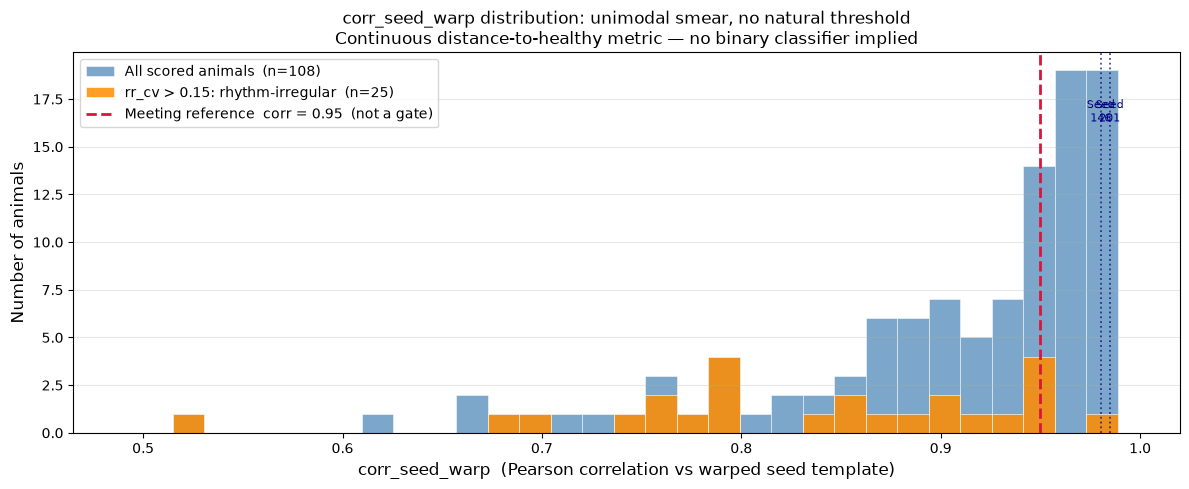

Saved: E:\data_vishva\outputs\figures\04_corr_seed_warp_histogram.png

Bimodality check (n=108 scored animals):
  range : 0.5150 -- 0.9888
  below 0.95 : 64 animals  (highest: 0.9477)
  above 0.95 : 44 animals  (lowest : 0.9504)
  gap at 0.95 : 0.0028  --> NO NATURAL BOUNDARY


In [6]:
# --- Histogram: corr_seed_warp distribution -- the absence of a threshold ----
# PRIMARY THESIS RESULT: the distribution is a unimodal smear with no bimodality
# and no natural gap at any threshold.  A binary gate off any value in this range
# would impose an arbitrary boundary, not identify one.

scored_corr    = score_df['corr_seed_warp'].dropna()
rr_flag_corr   = score_df.loc[score_df['rr_cv_flag'], 'corr_seed_warp'].dropna()

fig_h, ax_h = plt.subplots(figsize=(12, 5))

_, bins, _ = ax_h.hist(
    scored_corr, bins=30,
    color='steelblue', alpha=0.70, edgecolor='white', linewidth=0.5,
    label=f'All scored animals  (n={len(scored_corr)})')

if len(rr_flag_corr):
    ax_h.hist(
        rr_flag_corr, bins=bins,
        color='darkorange', alpha=0.85, edgecolor='white', linewidth=0.5,
        label=f'rr_cv > {RR_CV_FLAG_THRESHOLD}: rhythm-irregular  (n={len(rr_flag_corr)})')

ax_h.axvline(
    CORR_ADMIT_MIN, color='crimson', lw=2.0, linestyle='--',
    label=f'Meeting reference  corr = {CORR_ADMIT_MIN}  (not a gate)')

# Seed positions
y_top = ax_h.get_ylim()[1]
for sid in SEED_ANIMAL_IDS:
    row_s = score_df[score_df['animal_id'] == sid]
    if len(row_s) and pd.notna(row_s.iloc[0]['corr_seed_warp']):
        c = row_s.iloc[0]['corr_seed_warp']
        ax_h.axvline(c, color='navy', lw=1.3, linestyle=':', alpha=0.7)
        ax_h.text(c, y_top * 0.88, f'Seed\n{sid}',
                  ha='center', va='top', fontsize=8, color='navy')

ax_h.set_xlabel('corr_seed_warp  (Pearson correlation vs warped seed template)', fontsize=12)
ax_h.set_ylabel('Number of animals', fontsize=12)
ax_h.set_title(
    'corr_seed_warp distribution: unimodal smear, no natural threshold\n'
    'Continuous distance-to-healthy metric — no binary classifier implied',
    fontsize=12)
ax_h.legend(fontsize=10, loc='upper left')
ax_h.grid(axis='y', alpha=0.3)
ax_h.set_xlim(max(0, float(scored_corr.min()) - 0.05), 1.02)
fig_h.tight_layout()

out_hist = FIGURES_DIR / '04_corr_seed_warp_histogram.png'
fig_h.savefig(out_hist, dpi=150)
plt.show()
print(f'Saved: {out_hist}')

# Bimodality summary (printed result for thesis)
print(f'\nBimodality check (n={len(scored_corr)} scored animals):')
print(f'  range : {scored_corr.min():.4f} -- {scored_corr.max():.4f}')
b = scored_corr[scored_corr < CORR_ADMIT_MIN]
a = scored_corr[scored_corr >= CORR_ADMIT_MIN]
if len(b) and len(a):
    g = a.min() - b.max()
    print(f'  below {CORR_ADMIT_MIN} : {len(b)} animals  (highest: {b.max():.4f})')
    print(f'  above {CORR_ADMIT_MIN} : {len(a)} animals  (lowest : {a.min():.4f})')
    print(f'  gap at {CORR_ADMIT_MIN} : {g:.4f}  --> NO NATURAL BOUNDARY')

## Step 2 — PROVISIONAL reference template (seeds only)

Template = seeds [201, 146] only — two manually-validated animals.

**Why seeds only, not the 44?**  Using the 44-animal gate-selected set would be
circular: the same `corr_seed_warp` metric that scores all animals was also used to
decide who contributes to the reference for that metric.  A defensible reference
must be grounded in independent evidence (manual LabChart validation, confirmed
treatment group membership) — not a threshold with no natural gap.

The ±1 SD variability band here reflects inter-seed variation, not population spread.
Rebuild from confirmed controls once treatment metadata is available.

In [7]:
# PROVISIONAL reference template -- seeds only.
# admitted_ids = template_core_ids = SEED_ANIMAL_IDS  (set in cell-widen).
#
# Rationale: avoids circular definition.  The 44-animal set from the 0.95 gate
# was selected using the same corr_seed_warp metric used to score all animals;
# building the template from that set feeds back into itself.  Seeds are
# grounded in independent evidence (manual LabChart validation).
#
# Rebuild from confirmed controls once treatment metadata is available.

admitted_norm_beats = []
admitted_raw_beats  = []
admitted_warp_beats = []

for aid in admitted_ids:
    rec    = all_animal_beats[aid]
    mb     = rec['mean_beat']
    nb     = normalise_beat(mb, rec['t_ms'])
    med_rr = rec.get('median_rr_ms', np.nan)
    if nb is not None:
        admitted_norm_beats.append(nb)
        admitted_raw_beats.append(mb)
        if not np.isnan(med_rr):
            admitted_warp_beats.append(warp_beat(nb, rec['t_ms'], med_rr))

norm_stack = np.vstack(admitted_norm_beats)
raw_stack  = np.vstack(admitted_raw_beats)
warp_stack = np.vstack(admitted_warp_beats)

template_norm   = norm_stack.mean(axis=0)         # (250,) fixed-ms shape template
template_raw    = raw_stack.mean(axis=0)           # (250,) raw-mV template
template_warped = warp_stack.mean(axis=0)          # (200,) warped shape template (PRIMARY)
sd_band         = norm_stack.std(axis=0, ddof=1)   # ±1 SD, fixed-ms
sd_band_warped  = warp_stack.std(axis=0, ddof=1)   # ±1 SD, warped

print(f'PROVISIONAL template built from {len(admitted_ids)} animals: {admitted_ids}')
print(f'  (seeds only -- rebuild from confirmed controls after treatment metadata)')
print(f'  Fixed-ms window : {t_ms_ref[0]:.0f} to {t_ms_ref[-1]:.0f} ms '
      f'({len(template_norm)} samples)')
print(f'  Warped axis     : -{WARP_PRE_FRAC} to +{WARP_POST_FRAC} of RR '
      f'({len(template_warped)} samples)')
print(f'  SD band (warped): max={sd_band_warped.max():.4f}  '
      f'mean={sd_band_warped.mean():.4f}  (inter-seed variation only)')
if len(admitted_warp_beats) < len(admitted_ids):
    print(f'  WARNING: {len(admitted_ids) - len(admitted_warp_beats)} animal(s) had no '
          f'median_rr_ms and were excluded from the warped template.')

PROVISIONAL template built from 2 animals: [201, 146]
  (seeds only -- rebuild from confirmed controls after treatment metadata)
  Fixed-ms window : -100 to 149 ms (250 samples)
  Warped axis     : -0.15 to +0.6 of RR (200 samples)
  SD band (warped): max=0.1847  mean=0.0442  (inter-seed variation only)


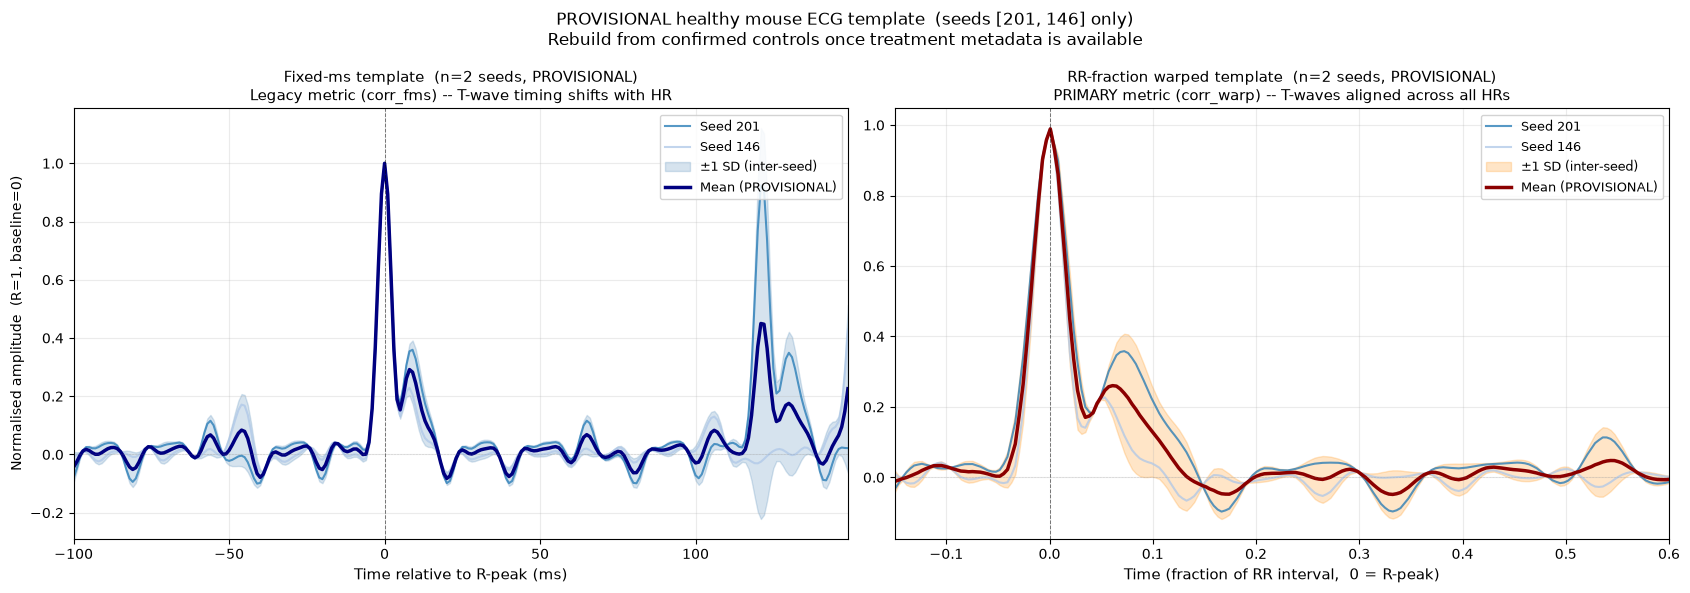

Saved: E:\data_vishva\outputs\figures\04_healthy_template_normalised.png


In [8]:
# --- Figure 1: Fixed-ms vs RR-fraction warped templates side by side --------
# Left  panel: fixed-ms (legacy) -- shows T-wave position shifts by HR
# Right panel: warped (primary) -- T-waves aligned regardless of HR
# Template is PROVISIONAL (seeds only); n reflects the 2-seed core.
cmap = plt.cm.tab20
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Left: fixed-ms normalised template
ax = axes[0]
for i, (aid, nb) in enumerate(zip(admitted_ids, admitted_norm_beats)):
    ax.plot(t_ms_ref, nb, color=cmap(i % 20), lw=1.5, alpha=0.75, label=f'Seed {aid}')
ax.fill_between(t_ms_ref, template_norm - sd_band, template_norm + sd_band,
                alpha=0.22, color='steelblue', label=r'$\pm$1 SD (inter-seed)')
ax.plot(t_ms_ref, template_norm, color='navy', lw=2.5, label='Mean (PROVISIONAL)')
ax.axvline(0, color='k', lw=0.7, linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', lw=0.4, linestyle=':', alpha=0.5)
ax.set_xlabel('Time relative to R-peak (ms)', fontsize=11)
ax.set_ylabel('Normalised amplitude  (R=1, baseline=0)', fontsize=10)
ax.set_title(
    f'Fixed-ms template  (n={len(admitted_ids)} seeds, PROVISIONAL)\n'
    'Legacy metric (corr_fms) -- T-wave timing shifts with HR',
    fontsize=11)
ax.legend(loc='upper right', fontsize=9, framealpha=0.85)
ax.grid(alpha=0.25)
ax.set_xlim(t_ms_ref[0], t_ms_ref[-1])

# Right: RR-fraction warped template (PRIMARY)
ax = axes[1]
for i, (aid, wb) in enumerate(zip(admitted_ids, admitted_warp_beats)):
    ax.plot(WARP_FRAC_AXIS, wb, color=cmap(i % 20), lw=1.5, alpha=0.75, label=f'Seed {aid}')
ax.fill_between(WARP_FRAC_AXIS,
                template_warped - sd_band_warped,
                template_warped + sd_band_warped,
                alpha=0.22, color='darkorange', label=r'$\pm$1 SD (inter-seed)')
ax.plot(WARP_FRAC_AXIS, template_warped, color='darkred', lw=2.5,
        label='Mean (PROVISIONAL)')
ax.axvline(0, color='k', lw=0.7, linestyle='--', alpha=0.5)
ax.axhline(0, color='gray', lw=0.4, linestyle=':', alpha=0.5)
ax.set_xlabel('Time (fraction of RR interval,  0 = R-peak)', fontsize=11)
ax.set_title(
    f'RR-fraction warped template  (n={len(admitted_warp_beats)} seeds, PROVISIONAL)\n'
    'PRIMARY metric (corr_warp) -- T-waves aligned across all HRs',
    fontsize=11)
ax.legend(loc='upper right', fontsize=9, framealpha=0.85)
ax.grid(alpha=0.25)
ax.set_xlim(-WARP_PRE_FRAC, WARP_POST_FRAC)

fig.suptitle(
    f'PROVISIONAL healthy mouse ECG template  (seeds {admitted_ids} only)\n'
    'Rebuild from confirmed controls once treatment metadata is available',
    fontsize=12)
fig.tight_layout()
out1 = FIGURES_DIR / '04_healthy_template_normalised.png'
fig.savefig(out1, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out1}')

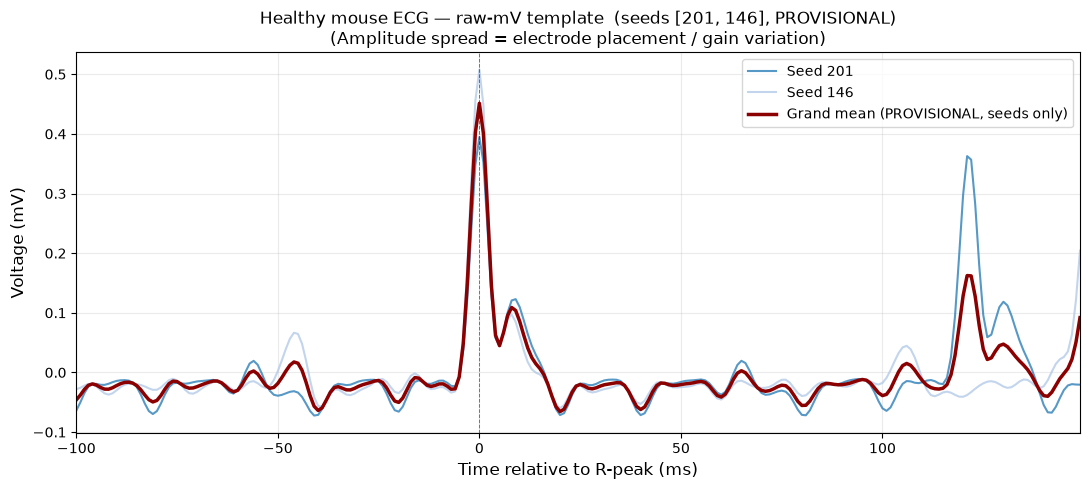

Saved: E:\data_vishva\outputs\figures\04_healthy_template_raw_mV.png


In [9]:
# --- Figure 2: Raw-mV template -----------------------------------------------
fig2, ax2 = plt.subplots(figsize=(11, 5))

for i, (aid, rb) in enumerate(zip(admitted_ids, admitted_raw_beats)):
    ax2.plot(t_ms_ref, rb, color=cmap(i % 20), lw=1.5, alpha=0.75, label=f'Seed {aid}')

ax2.plot(t_ms_ref, template_raw, color='darkred', lw=2.5,
         label='Grand mean (PROVISIONAL, seeds only)')
ax2.axvline(0, color='k', lw=0.7, linestyle='--', alpha=0.5)

ax2.set_xlabel('Time relative to R-peak (ms)', fontsize=12)
ax2.set_ylabel('Voltage (mV)', fontsize=12)
ax2.set_title(
    f'Healthy mouse ECG — raw-mV template  (seeds {admitted_ids}, PROVISIONAL)\n'
    '(Amplitude spread = electrode placement / gain variation)',
    fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.25)
ax2.set_xlim(t_ms_ref[0], t_ms_ref[-1])
fig2.tight_layout()
out2 = FIGURES_DIR / '04_healthy_template_raw_mV.png'
fig2.savefig(out2, dpi=150)
plt.show()
print(f'Saved: {out2}')

In [10]:
# --- Continuous morphology score table + rhythm audit -----------------------
print('=' * 145)
print('STEP 1 -- CONTINUOUS MORPHOLOGY SCORES AND RHYTHM AUDIT')
print(f'Reference    : warped seed template (PROVISIONAL -- seeds {SEED_ANIMAL_IDS} only)')
print(f'Primary      : corr_seed_warp (continuous; 0.95 from meeting = reference marker only)')
print(f'Rhythm flag  : rr_cv > {RR_CV_FLAG_THRESHOLD}  '
      f'(morphology-clean + rhythm-irregular = distinct category)')
print(f'Hard excludes: {sorted(HARD_EXCLUDE_IDS)}')
print('=' * 145)

disp = score_df.copy()
for col in ['rr_cv', 'corr_seed_fms', 'rmse_seed_fms', 'corr_seed_warp', 'rmse_seed_warp']:
    disp[col] = disp[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'nan')

with pd.option_context('display.max_rows', 200, 'display.max_colwidth', 50, 'display.width', 290):
    print(disp[['animal_id', 'n_beats', 'rr_cv',
                'corr_seed_fms', 'rmse_seed_fms',
                'corr_seed_warp', 'rmse_seed_warp',
                'rr_cv_flag', 'note']].to_string(index=False))

# Rhythm-irregular summary
flagged = score_df[score_df['rr_cv_flag']].sort_values('corr_seed_warp', ascending=False)
print(f'\n--- Morphology-clean + rhythm-irregular (rr_cv > {RR_CV_FLAG_THRESHOLD}) ---')
if len(flagged):
    print(f'  {"ID":>4}  {"corr_warp":>10}  {"rr_cv":>7}  '
          f'(seed rr_cv range: 0.0705-0.1038)')
    for _, r in flagged.iterrows():
        c = r['corr_seed_warp']
        rv = r['rr_cv']
        c_s  = f'{c:.4f}'  if pd.notna(c)  else 'nan'
        rv_s = f'{rv:.4f}' if pd.notna(rv) else 'nan'
        print(f'  {int(r["animal_id"]):>4}  {c_s:>10}  {rv_s:>7}')
else:
    print('  None')

print(f'\nTotal OK animals scored : {n_scored}')
print(f'rr_cv_flagged           : {n_rr_flagged}')
print(f'Template core           : {admitted_ids}  (PROVISIONAL, seeds only)')

STEP 1 -- CONTINUOUS MORPHOLOGY SCORES AND RHYTHM AUDIT
Reference    : warped seed template (PROVISIONAL -- seeds [201, 146] only)
Primary      : corr_seed_warp (continuous; 0.95 from meeting = reference marker only)
Rhythm flag  : rr_cv > 0.15  (morphology-clean + rhythm-irregular = distinct category)
Hard excludes: [106, 109, 111, 113, 115, 117, 120]
 animal_id  n_beats  rr_cv corr_seed_fms rmse_seed_fms corr_seed_warp rmse_seed_warp  rr_cv_flag         note
       245      230 0.1927        0.6825        0.1171         0.9888         0.0299        True       scored
       256      136 0.0114        0.9261        0.0677         0.9872         0.0321       False       scored
       153      305 0.0716        0.8389        0.0945         0.9866         0.0346       False       scored
       141      635 0.1391        0.9013        0.0635         0.9865         0.0327       False       scored
       243      192 0.0104        0.9108        0.0720         0.9863         0.0333       Fals

In [11]:
# --- Save template arrays + scoring audit (inputs to Phase 4) ---------------
np.save(OUTPUTS_DIR / 'healthy_template_norm.npy',           template_norm)
np.save(OUTPUTS_DIR / 'healthy_template_raw_mV.npy',         template_raw)
np.save(OUTPUTS_DIR / 'healthy_template_sd_band.npy',        sd_band)
np.save(OUTPUTS_DIR / 'healthy_template_t_ms.npy',           t_ms_ref)
np.save(OUTPUTS_DIR / 'healthy_template_warped.npy',         template_warped)
np.save(OUTPUTS_DIR / 'healthy_template_warp_frac_axis.npy', WARP_FRAC_AXIS)

score_df.to_csv(OUTPUTS_DIR / 'healthy_template_selection_audit.csv', index=False)

meta = {
    'provisional':        True,
    'template_core_ids':  template_core_ids,
    'seed_ids':           SEED_ANIMAL_IDS,
    'note':               (
        'PROVISIONAL: seeds only. Rebuild from confirmed controls '
        'once treatment metadata is available.'
    ),
    'corr_ref_meeting':   CORR_ADMIT_MIN,
    'corr_ref_note':      'reference marker only -- not a binary gate',
    'rmse_admit_tol':     RMSE_ADMIT_TOL,
    'rr_cv_flag_threshold': RR_CV_FLAG_THRESHOLD,
    'warp_pre_frac':      WARP_PRE_FRAC,
    'warp_post_frac':     WARP_POST_FRAC,
    'warp_grid_n':        WARP_GRID_N,
    'n_samples_fms':      int(len(template_norm)),
    'n_samples_warp':     int(len(template_warped)),
    't_ms_start':         float(t_ms_ref[0]),
    't_ms_end':           float(t_ms_ref[-1]),
    'n_scored':           n_scored,
    'n_rr_flagged':       n_rr_flagged,
}
with open(OUTPUTS_DIR / 'healthy_template_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
for fname in ['healthy_template_norm.npy', 'healthy_template_raw_mV.npy',
              'healthy_template_sd_band.npy', 'healthy_template_t_ms.npy',
              'healthy_template_warped.npy', 'healthy_template_warp_frac_axis.npy',
              'healthy_template_selection_audit.csv', 'healthy_template_meta.json']:
    print(f'  {OUTPUTS_DIR / fname}')

Saved:
  E:\data_vishva\outputs\healthy_template_norm.npy
  E:\data_vishva\outputs\healthy_template_raw_mV.npy
  E:\data_vishva\outputs\healthy_template_sd_band.npy
  E:\data_vishva\outputs\healthy_template_t_ms.npy
  E:\data_vishva\outputs\healthy_template_warped.npy
  E:\data_vishva\outputs\healthy_template_warp_frac_axis.npy
  E:\data_vishva\outputs\healthy_template_selection_audit.csv
  E:\data_vishva\outputs\healthy_template_meta.json


## Step 3 — Distance-to-healthy for every animal

Score every animal (OK, NEEDS\_REVIEW, and failed) against the PROVISIONAL
healthy templates (seeds 201 and 146 only).

Two representations per animal:

- **`corr_to_tmpl_warp` / `rmse_to_tmpl_warp`** (PRIMARY) — compared in RR-fraction
  warped space against `template_warped`. Heart-rate confound removed.
- **`corr_to_tmpl_fms` / `rmse_to_tmpl_fms`** (secondary / legacy) — compared in
  fixed-ms space against `template_norm`. Kept for audit and back-compatibility.

Additional columns:

- **`rr_cv`** — RR coefficient of variation for every animal.
- **`rr_cv_flag`** — True when `rr_cv > RR_CV_FLAG_THRESHOLD` (0.15). Animals that
  score well on morphology but have elevated rhythm variability are a distinct
  informative category, **not** healthy baseline.

Animals with no valid averaged beat, or with no `median_rr_ms` (needed for warping),
receive NULL in the warped columns — not zero. The NULL is **informative**: it means
no repeating morphology was detectable, which is a pathological or technical signal
in its own right and will feed Phase 4 directly.

In [12]:
# Build rr_cv_flag lookup from score_df (covers all OK animals)
rr_cv_flag_map = score_df.set_index('animal_id')['rr_cv_flag'].to_dict()

distance_rows = []

for aid in sorted(all_animal_beats.keys()):
    rec     = all_animal_beats[aid]
    status  = rec.get('status', 'UNKNOWN')
    n_beats = rec.get('n_beats', 0)
    mb      = rec.get('mean_beat')
    t_ms_a  = rec.get('t_ms')
    med_rr  = rec.get('median_rr_ms', np.nan)
    rr_cv_a = rec.get('rr_cv', np.nan)
    in_tmpl = aid in admitted_ids

    corr_warp = rmse_warp = corr_fms = rmse_fms = np.nan
    null_reason = None

    if mb is None or t_ms_a is None:
        null_reason = 'no_mean_beat'
    elif n_beats < 2:
        null_reason = 'too_few_beats'
    else:
        nb = normalise_beat(mb, t_ms_a)
        if nb is None:
            null_reason = 'normalise_failed'
        else:
            # Warped score vs warped template (PRIMARY)
            if not np.isnan(med_rr):
                wb = warp_beat(nb, t_ms_a, med_rr)
                try:
                    corr_warp = float(pearsonr(template_warped, wb)[0])
                    rmse_warp = float(np.sqrt(np.mean((template_warped - wb) ** 2)))
                except Exception:
                    null_reason = 'warp_pearsonr_failed'

            # Fixed-ms score vs fixed-ms template (legacy)
            nb_fms = (nb if len(nb) == len(template_norm)
                      else np.interp(t_ms_ref, t_ms_a, nb))
            try:
                corr_fms = float(pearsonr(template_norm, nb_fms)[0])
                rmse_fms = float(np.sqrt(np.mean((template_norm - nb_fms) ** 2)))
            except Exception:
                pass

    distance_rows.append({
        'animal_id':         aid,
        'status':            status,
        'n_beats':           n_beats,
        'rr_cv':             rr_cv_a,
        'rr_cv_flag':        bool(rr_cv_flag_map.get(aid, False)),
        'corr_to_tmpl_warp': corr_warp,   # PRIMARY
        'rmse_to_tmpl_warp': rmse_warp,
        'corr_to_tmpl_fms':  corr_fms,
        'rmse_to_tmpl_fms':  rmse_fms,
        'in_template':       in_tmpl,
        'null_reason':       null_reason or '',
    })

dist_df = pd.DataFrame(distance_rows)
dist_df_ranked = dist_df.sort_values(
    'rmse_to_tmpl_warp', ascending=True, na_position='last'
).reset_index(drop=True)

null_animals = dist_df[dist_df['rmse_to_tmpl_warp'].isna()].copy()

print(f'Animals scored : {len(dist_df)}')
print(f'  Valid warped scores : {dist_df["rmse_to_tmpl_warp"].notna().sum()}')
print(f'  NULL warped scores  : {len(null_animals)}')
if len(null_animals):
    for _, r in null_animals.iterrows():
        print(f'    Animal {int(r["animal_id"])}: {r["null_reason"]}')

dist_df_ranked.to_csv(OUTPUTS_DIR / 'distance_to_healthy.csv', index=False)
print(f'\nSaved: {OUTPUTS_DIR / "distance_to_healthy.csv"}')

Animals scored : 118
  Valid warped scores : 117
  NULL warped scores  : 1
    Animal 110: no_mean_beat

Saved: E:\data_vishva\outputs\distance_to_healthy.csv


In [13]:
print('=' * 140)
print('STEP 3 -- DISTANCE-TO-HEALTHY RANKING')
print('Sorted by rmse_to_tmpl_warp (PRIMARY, RR-fraction warped) ascending; NULLs at bottom.')
print(f'Reference : PROVISIONAL warped template  (seeds {admitted_ids} only)')
print(f'Primary   : corr_to_tmpl_warp, rmse_to_tmpl_warp')
print(f'Secondary : corr_to_tmpl_fms,  rmse_to_tmpl_fms  (fixed-ms, legacy audit)')
print(f'rr_cv_flag: rr_cv > {RR_CV_FLAG_THRESHOLD}  '
      f'(morphology-clean + rhythm-irregular = distinct category)')
print(f'NULL      : no valid mean beat or no median_rr_ms  '
      f'-- informative missingness (feeds Phase 4)')
print('=' * 140)

disp3 = dist_df_ranked.copy()
for col in ['rr_cv', 'corr_to_tmpl_warp', 'rmse_to_tmpl_warp',
            'corr_to_tmpl_fms', 'rmse_to_tmpl_fms']:
    disp3[col] = disp3[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'NULL')

with pd.option_context('display.max_rows', 200, 'display.width', 260):
    print(disp3[['animal_id', 'status', 'n_beats', 'rr_cv',
                 'corr_to_tmpl_warp', 'rmse_to_tmpl_warp',
                 'corr_to_tmpl_fms',  'rmse_to_tmpl_fms',
                 'in_template', 'rr_cv_flag', 'null_reason']].to_string(index=False))

# NULL animals (informative missingness)
if len(null_animals) > 0:
    print('\n--- NULL warped distances (informative missingness -- feeds Phase 4) ---')
    for _, row in null_animals.sort_values('animal_id').iterrows():
        print(f'  Animal {int(row["animal_id"]):>4}  status={row["status"]:<16}'
              f'  n_beats={int(row["n_beats"]) if pd.notna(row["n_beats"]) else 0:<4}'
              f'  reason={row["null_reason"]}')

# Rhythm-irregular summary from distance table
rr_flagged_dist = dist_df_ranked[dist_df_ranked['rr_cv_flag']].copy()
if len(rr_flagged_dist):
    print(f'\n--- Morphology-clean + rhythm-irregular  (rr_cv > {RR_CV_FLAG_THRESHOLD}) ---')
    print(f'  Score well on morphology but have elevated RR variability.')
    print(f'  NOT classified as healthy -- treat as distinct category in Phase 4.')
    for _, r in rr_flagged_dist.iterrows():
        cw_s = f'{r["corr_to_tmpl_warp"]:.4f}' if pd.notna(r['corr_to_tmpl_warp']) else 'nan'
        cv_s = f'{r["rr_cv"]:.4f}'              if pd.notna(r['rr_cv'])              else 'nan'
        print(f'  Animal {int(r["animal_id"]):>4}  '
              f'corr_to_tmpl_warp={cw_s}  rr_cv={cv_s}')

# Sanity check
print('\n' + '=' * 140)
print('SANITY CHECK -- pathological animals should rank at far end (high RMSE / low corr)')
print('=' * 140)
n_valid = int(dist_df_ranked['rmse_to_tmpl_warp'].notna().sum())

for check_id, label in [
        (111, 'Animal 111 (NEEDS_REVIEW, pathological suspect)'),
        (115, 'Animal 115 (hard-excluded, RR variability outlier)')]:
    rows = dist_df_ranked[dist_df_ranked['animal_id'] == check_id]
    if len(rows) == 0:
        print(f'  {label}: not in dataset')
        continue
    row  = rows.iloc[0]
    rank = int(rows.index[0]) + 1
    warp_rmse = f'{row["rmse_to_tmpl_warp"]:.4f}' if pd.notna(row['rmse_to_tmpl_warp']) else 'NULL'
    warp_corr = f'{row["corr_to_tmpl_warp"]:.4f}' if pd.notna(row['corr_to_tmpl_warp']) else 'NULL'
    fms_rmse  = f'{row["rmse_to_tmpl_fms"]:.4f}'  if pd.notna(row['rmse_to_tmpl_fms'])  else 'NULL'
    fms_corr  = f'{row["corr_to_tmpl_fms"]:.4f}'  if pd.notna(row['corr_to_tmpl_fms'])  else 'NULL'
    print(f'  {label}')
    print(f'    warped : rmse={warp_rmse}  corr={warp_corr}  rank={rank}/{n_valid}')
    print(f'    fms    : rmse={fms_rmse}   corr={fms_corr}')

STEP 3 -- DISTANCE-TO-HEALTHY RANKING
Sorted by rmse_to_tmpl_warp (PRIMARY, RR-fraction warped) ascending; NULLs at bottom.
Reference : PROVISIONAL warped template  (seeds [201, 146] only)
Primary   : corr_to_tmpl_warp, rmse_to_tmpl_warp
Secondary : corr_to_tmpl_fms,  rmse_to_tmpl_fms  (fixed-ms, legacy audit)
rr_cv_flag: rr_cv > 0.15  (morphology-clean + rhythm-irregular = distinct category)
NULL      : no valid mean beat or no median_rr_ms  -- informative missingness (feeds Phase 4)
 animal_id            status  n_beats  rr_cv corr_to_tmpl_warp rmse_to_tmpl_warp corr_to_tmpl_fms rmse_to_tmpl_fms  in_template  rr_cv_flag  null_reason
       245                OK      230 0.1927            0.9888            0.0299           0.6825           0.1171        False        True             
       256                OK      136 0.0114            0.9872            0.0321           0.9261           0.0677        False       False             
       141                OK      635 0.1391       